# Wine Price Prediction: PCA-Reduced MPNet Embeddings + CatBoost

## 基本情報

- 主題: Text embeddingをPCAで次元削減してCatBoostへ投入する
- 作成者: 荒田禎之
- 使用データ: Wine Review
- 分析課題: 数値・カテゴリ変数・レビュー本文から $\log(\mathrm{price})$ を予測する
- encoder: `sentence-transformers/all-mpnet-base-v2`
- 次元削減: PCA（768次元から8次元）

固定encoderから得た768次元embeddingをCatBoostへ直接投入せず、訓練データだけでfitしたPCAによって8次元へ圧縮する。PCAのfitに検証・テストデータを使わないことで、前処理段階の情報漏洩を防ぎます。

This notebook includes code and explanations generated with OpenAI Codex.


In [2]:
#!pip install -q -U catboost

### ライブラリと乱数シードを準備するコード

ファイル操作、データ処理、可視化、GPU確認、文章embedding生成、PCA、CatBoost回帰、データ分割、評価に必要なライブラリを読み込む。

`SentenceTransformer` はレビュー本文のベクトル化、`PCA` はembeddingの次元削減、`torch` はGPUの利用可否確認に使用します。乱数seedを42に固定し、データ分割、PCA、CatBoostの再現性を高める。


In [3]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U sentence-transformers catboost scikit-learn

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from catboost import CatBoostRegressor
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
SEED = 42


## 1. データの読み込みと重複除外

`wine_review_CatBoost.ipynb` と同じ条件にするため、`title` と `description` の組が重複する行を除外します。価格が欠損または非正の行も除外する。

使用する数値列とカテゴリ列を定義し、必要な列だけCSVから読み込む。`title` と `description` の組が同じレビューを除外した後、本文と正の価格がある行だけを残す。カテゴリ欠損は `__MISSING__` として保持し、読み込み元、重複削除数、最終行数、先頭行を表示する。


In [ ]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

numeric_features = ["points"]
categorical_features = [
    "country",
    "designation",
    "province",
    "region_1",
    "region_2",
    "variety",
    "winery",
]
feature_source_columns = ["description", "price"] + numeric_features + categorical_features
read_columns = ["title"] + feature_source_columns

df = pd.read_csv(csv_path, usecols=read_columns)
rows_before = len(df)
df = df.drop_duplicates(subset=["title", "description"]).copy()
duplicates_removed = rows_before - len(df)

model_data = (
    df.loc[
        df["description"].notna()
        & df["price"].notna()
        & (df["price"] > 0),
        feature_source_columns,
    ]
    .reset_index(drop=True)
)

for column in categorical_features:
    model_data[column] = model_data[column].fillna("__MISSING__").astype(str)

print(f"Loaded: {csv_path.resolve()}")
print(f"Original rows: {rows_before:,}")
print(f"Removed duplicated reviews: {duplicates_removed:,}")
print(f"Rows used after deduplication and price filtering: {len(model_data):,}")
display(model_data.head())

## 2. all-mpnet-base-v2による768次元embedding生成

<!-- `SentenceTransformer.encode` は推論モードで実行されます。全パラメータの勾配も無効化し、encoderをfine-tuningしないことを明示します。 -->

`sentence-transformers/all-mpnet-base-v2` の標準768次元embeddingを出力します。その後、訓練データから推定したPCAで8次元へ削減することで、データ中の分散を考慮した圧縮を行います。

動作確認時は `MAX_ROWS` を指定できます。embedding生成自体は目的変数を使わないため分割前に一括実行できますが、PCAのfitは必ず分割後の訓練embeddingだけで行います。


In [5]:
ENCODER_NAME = "sentence-transformers/all-mpnet-base-v2"
EMBEDDING_DIM = 768
PCA_COMPONENTS = 8
BATCH_SIZE = 64
MAX_ROWS = None  # 例: 10_000。全データを使う場合は None

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    model_data = model_data.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
encoder = SentenceTransformer(
    ENCODER_NAME,
    device=device,
)
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad_(False)

print(f"Encoder device: {device}")
embeddings = encoder.encode(
    model_data["description"].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

print(f"Embedding shape before PCA: {embeddings.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoder device: cuda


Batches:   0%|          | 0/1744 [00:00<?, ?it/s]

Embedding shape before PCA: (111593, 768)


## 3. データ分割とPCAによる次元削減

最初に行番号を80%の訓練、10%の検証、10%のテストへ分割します。表形式特徴、embedding、目的変数のすべてに同じ行番号を使います。

PCAは訓練embeddingだけでfitします。検証・テストembeddingは、訓練データから得た平均ベクトルと主成分によってtransformするだけです。全データでPCAをfitすると、ラベルを直接使わなくても検証・テストの分布情報が前処理へ混入するため採用しません。

768次元を `PCA_COMPONENTS=8` へ削減し、`embedding_pca_000` から始まる数値列として表形式特徴へ結合します。


In [ ]:
all_indices = np.arange(len(model_data))
train_indices, holdout_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=SEED,
)
valid_indices, test_indices = train_test_split(
    holdout_indices,
    test_size=0.5,
    random_state=SEED,
)

y = np.log(model_data["price"]).astype("float32")
y_train = y.iloc[train_indices].reset_index(drop=True)
y_valid = y.iloc[valid_indices].reset_index(drop=True)
y_test = y.iloc[test_indices].reset_index(drop=True)

pca = PCA(
    n_components=PCA_COMPONENTS,
    svd_solver="randomized",
    random_state=SEED,
)
train_embedding_pca = pca.fit_transform(embeddings[train_indices]).astype("float32")
valid_embedding_pca = pca.transform(embeddings[valid_indices]).astype("float32")
test_embedding_pca = pca.transform(embeddings[test_indices]).astype("float32")

embedding_features = [
    f"embedding_pca_{i:03d}" for i in range(PCA_COMPONENTS)
]
base_features = numeric_features + categorical_features


def build_feature_frame(indices, reduced_embeddings):
    tabular = model_data.iloc[indices][base_features].reset_index(drop=True)
    reduced_frame = pd.DataFrame(
        reduced_embeddings,
        columns=embedding_features,
    )
    return pd.concat([tabular, reduced_frame], axis=1)


X_train = build_feature_frame(train_indices, train_embedding_pca)
X_valid = build_feature_frame(valid_indices, valid_embedding_pca)
X_test = build_feature_frame(test_indices, test_embedding_pca)

del train_embedding_pca, valid_embedding_pca, test_embedding_pca, embeddings

print(
    f"Train: {len(X_train):,}, validation: {len(X_valid):,}, "
    f"test: {len(X_test):,}"
)
print(f"PCA-reduced feature matrix: {X_train.shape[1]:,} columns")
display(X_train.iloc[:3, :12])
display(y_train.describe().rename("log_price").to_frame())


## 4. PCAの説明分散比

各主成分の説明分散比と累積説明分散比を確認します。累積説明分散比は、元の768次元embeddingの分散のうち、8主成分で保持できた割合を表します。

説明分散比が低すぎる場合は `PCA_COMPONENTS` を16や32などへ増やします。ただし、説明分散が大きい方向が価格予測に重要とは限らないため、最終的な次元数は検証RMSEでも比較する必要があります。テストデータは次元数の選択に使いません。


,component,explained_variance_ratio,cumulative_explained_variance
3,4,0.029759,0.194817
4,5,0.027334,0.222151
5,6,0.025268,0.247419
6,7,0.022947,0.270366
7,8,0.020772,0.291138


Cumulative explained variance with 8 components: 29.11%


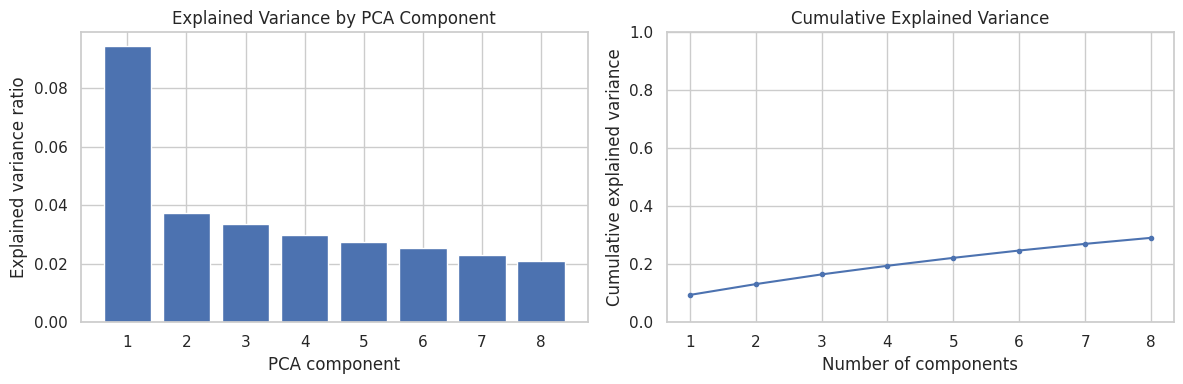

In [7]:
explained_variance = pd.DataFrame({
    "component": np.arange(1, PCA_COMPONENTS + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(
        pca.explained_variance_ratio_
    ),
})
display(explained_variance.tail())
print(
    f"Cumulative explained variance with {PCA_COMPONENTS} components: "
    f"{explained_variance['cumulative_explained_variance'].iloc[-1]:.2%}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(
    explained_variance["component"],
    explained_variance["explained_variance_ratio"],
)
axes[0].set(
    title="Explained Variance by PCA Component",
    xlabel="PCA component",
    ylabel="Explained variance ratio",
)
axes[1].plot(
    explained_variance["component"],
    explained_variance["cumulative_explained_variance"],
    marker="o",
    markersize=3,
)
axes[1].set(
    title="Cumulative Explained Variance",
    xlabel="Number of components",
    ylabel="Cumulative explained variance",
    ylim=(0, 1),
)
plt.tight_layout()
plt.show()


## 5. CatBoostの学習

GPUが利用可能な場合はCatBoostもGPUで学習します。検証RMSEに基づくearly stoppingを使用します。

利用可能な計算環境に応じてCatBoostをGPUまたはCPUで動かす。最大2,000 iteration、学習率0.05、深さ8、L2正則化5で回帰モデルを学習し、カテゴリ列は `cat_features` で直接指定する。検証RMSEが100 iteration改善しなければ停止し、検証性能が最良だったモデルを残す。


In [8]:
task_type = "GPU" if torch.cuda.is_available() else "CPU"
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=2_000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    task_type=task_type,
    allow_writing_files=False,
    verbose=100,
)

print(f"CatBoost task type: {task_type}")
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100,
    use_best_model=True,
)

print(f"Best iteration: {model.get_best_iteration():,}")

CatBoost task type: GPU
0:	learn: 0.6404436	test: 0.6395979	best: 0.6395979 (0)	total: 96.7ms	remaining: 3m 13s
100:	learn: 0.3567601	test: 0.3420604	best: 0.3420604 (100)	total: 3.38s	remaining: 1m 3s
200:	learn: 0.3443474	test: 0.3312727	best: 0.3312727 (200)	total: 5.72s	remaining: 51.2s
300:	learn: 0.3371154	test: 0.3259793	best: 0.3259793 (300)	total: 8.07s	remaining: 45.5s
400:	learn: 0.3317919	test: 0.3230609	best: 0.3230609 (400)	total: 10.5s	remaining: 41.7s
500:	learn: 0.3271673	test: 0.3209303	best: 0.3209303 (500)	total: 14.7s	remaining: 43.9s
600:	learn: 0.3231193	test: 0.3193076	best: 0.3193076 (600)	total: 17.2s	remaining: 40s
700:	learn: 0.3192383	test: 0.3177557	best: 0.3177557 (700)	total: 19.7s	remaining: 36.5s
800:	learn: 0.3157279	test: 0.3167419	best: 0.3167419 (800)	total: 22.2s	remaining: 33.2s
900:	learn: 0.3124590	test: 0.3158042	best: 0.3158042 (900)	total: 25.3s	remaining: 30.8s
1000:	learn: 0.3096245	test: 0.3153061	best: 0.3153061 (1000)	total: 28.9s	remai

## 6. テストデータでの評価

最終テストデータのlog価格を予測し、RMSE、MAE、$R^2$ を計算する。RMSEは大きな誤差を強く評価し、MAEは平均的な絶対誤差、$R^2$ はlog価格の変動を説明できた割合を表す。さらに指数変換でドル価格へ戻し、価格単位のMAEを算出する。


In [9]:
y_pred = model.predict(X_test)
metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_test, y_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_test, y_pred),
    "R2 (log price)": r2_score(y_test, y_pred),
    "MAE (price, USD)": mean_absolute_error(np.exp(y_test), np.exp(y_pred)),
})
display(metrics.to_frame("value"))

,value
RMSE (log price),0.315667
MAE (log price),0.233056
R2 (log price),0.775655
"MAE (price, USD)",9.843661


### 予測値と残差を可視化するコード

左図では実際のlog価格と予測log価格を比較し、45度の破線からの距離を予測誤差として確認する。右図では残差を「実際値 − 予測値」として表示する。0を中心に対称なら系統的な偏りが小さく、中心のずれや長い裾があれば過大・過小予測や外れた事例が存在する。


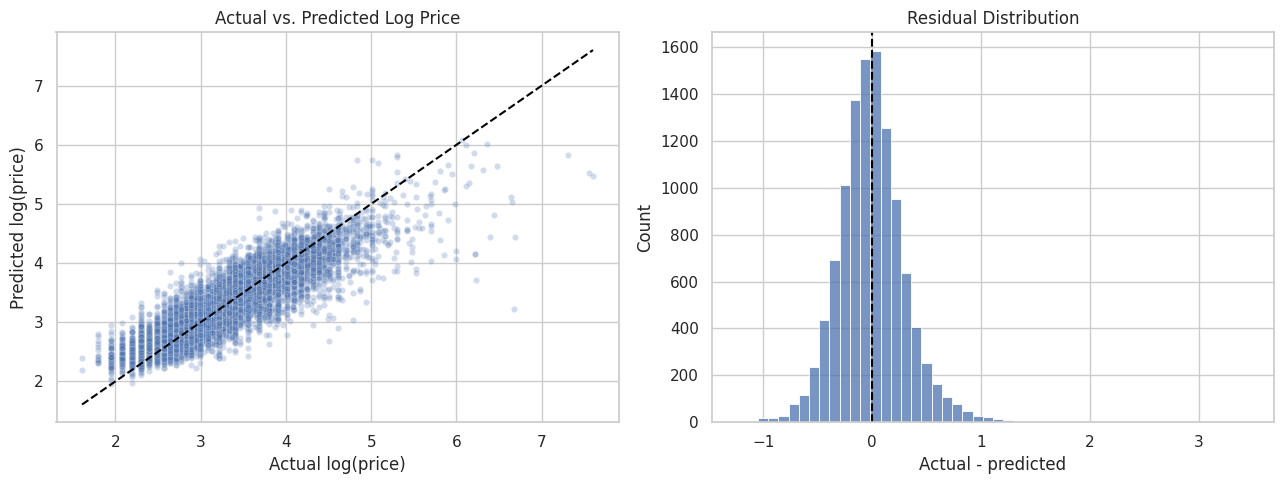

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 7. 特徴量重要度

個々のPCA主成分には直接的な意味を付けにくいため、8主成分の重要度を合計して `description_embedding_pca` として表示します。

CatBoostが返す全特徴量の重要度を列名と対応付けます。PCA主成分の重要度を1グループにまとめ、評価点やカテゴリ変数と並べることで、PCA圧縮されたレビュー本文全体が予測へどの程度利用されたかを確認します。


,importance
points,22.648242
description_embedding_pca,19.412308
region_1,16.325295
variety,10.304914
winery,10.225574
country,6.868071
designation,6.310232
province,4.487455
region_2,3.417910


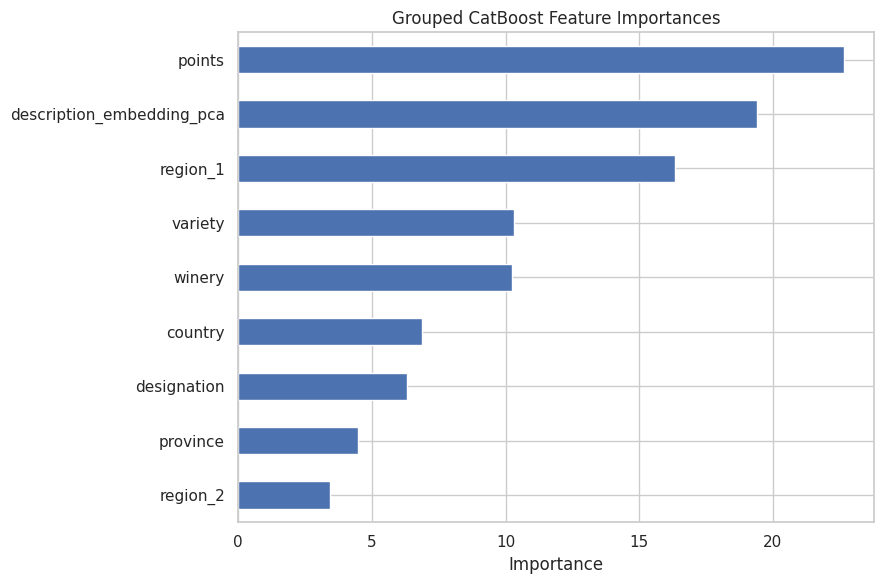

In [11]:
raw_importance = pd.Series(
    model.get_feature_importance(),
    index=X_train.columns,
    name="importance",
)
grouped_importance = pd.concat([
    raw_importance[numeric_features + categorical_features],
    pd.Series({
        "description_embedding_pca": raw_importance[embedding_features].sum(),
    }),
]).sort_values(ascending=False)

display(grouped_importance.rename("importance").to_frame())

plt.figure(figsize=(9, 6))
grouped_importance.sort_values().plot.barh()
plt.title("Grouped CatBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 8. 予測結果の例

テストデータの先頭10件を取り出し、表示用には元の数値・カテゴリ変数だけを残す。実際の価格とモデル予測を指数変換してドル単位で追加することで、embedding自体を表示せず、個別ワインの入力情報と価格誤差を読みやすい形で確認する。


In [ ]:
example_columns = numeric_features + categorical_features
prediction_examples = X_test.loc[:, example_columns].head(10).copy()
prediction_examples["actual_price"] = np.exp(y_test.head(10))
prediction_examples["predicted_price"] = np.exp(model.predict(X_test.head(10)))
display(prediction_examples)